# Métricas y Mecanismos de Validación de Modelos
## Unidad 2 · Clase 1 · Duración: 2 horas

**versión: 2025-1  |  modificado: 2026-04-06**

---

### 🗺️ Mapa de la clase

| Sección | Tema | Tiempo estimado |
|---------|------|-----------------|
| 1 | Métricas de clasificación: accuracy, precision, recall, F1 | 30 min |
| 2 | Curva ROC y AUC | 20 min |
| 3 | Métricas de regresión: MSE, MAE, R², RMSE | 20 min |
| 4 | Validación cruzada: k-fold, stratified, LOO | 20 min |
| 5 | Curvas de aprendizaje y validación | 15 min |
| 6 | Ejercicio en clase | 15 min |

---

### 📋 Prerequisitos

| Pregrado | Doctorado |
|----------|-----------|
| Train/test split, concepto de sobreajuste | Lo anterior + estimación de riesgo empírico |
| Matrices de confusión básicas | Descomposición bias-varianza |
| Pipeline de sklearn | Teorema de no-free-lunch |

---

---
<div style="background-color:#F8F9FA; border:2px solid #AEB6BF;
     padding:12px 18px; border-radius:8px; margin:10px 0;">
<strong>🎓 Modo de uso:</strong> Este notebook es compartido por dos cursos.<br><br>
<span style="color:#2E86C1; font-weight:bold;">🔵 Pregrado</span>
— Trabaja el contenido general y los bloques azules. Los bloques amarillos
son opcionales y te darán contexto adicional.<br><br>
<span style="color:#B7950B; font-weight:bold;">🟡 Doctorado</span>
— Trabaja el contenido general y <em>ambos</em> bloques. Los bloques azules
te ofrecen la intuición; los amarillos, la formalización.
</div>

---

In [ ]:
#!pip install numpy pandas matplotlib scikit-learn seaborn

In [4]:
# ── SETUP — NO MODIFICAR ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import __version__ as sklearn_version
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, KFold,
    LeaveOneOut, learning_curve, validation_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve,
    mean_squared_error, mean_absolute_error, r2_score
)

# Reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE) # Para cualquier función de numpy que use generación aleatoria

# Estilo visual
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Dataset clasificación: breast_cancer
# dataset: breast_cancer (sklearn built-in)  |  generado sintéticamente: no
data_clf = load_breast_cancer()
X_clf = pd.DataFrame(data_clf.data, columns=data_clf.feature_names)
y_clf = pd.Series(data_clf.target, name='target')

# Dataset regresión: diabetes
# dataset: diabetes (sklearn built-in)  |  generado sintéticamente: no
data_reg = load_diabetes()
X_reg = pd.DataFrame(data_reg.data, columns=data_reg.feature_names)
y_reg = pd.Series(data_reg.target, name='target')

# Splits train/test (ANTES de cualquier transformación)
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print(f'✅ Setup completo')
print(f'   numpy {np.__version__} · pandas {pd.__version__} · scikit-learn {sklearn_version}')
print(f'   Clasificación — train: {X_clf_train.shape}, test: {X_clf_test.shape}')
print(f'   Regresión     — train: {X_reg_train.shape}, test: {X_reg_test.shape}')

✅ Setup completo
   numpy 2.4.4 · pandas 3.0.2 · scikit-learn 1.8.0
   Clasificación — train: (455, 30), test: (114, 30)
   Regresión     — train: (353, 10), test: (89, 10)


---
## Sección 1 — Métricas de Clasificación

Dado un clasificador que predice una etiqueta $\hat{y} \in \{0, 1\}$ para cada muestra, necesitamos cuantificar **qué tan bien** clasifica. La **matriz de confusión** es el punto de partida:

```
                   Predicción
                 Negativo  Positivo
Real  Negativo |   TN    |   FP   |
      Positivo |   FN    |   TP   |
```

A partir de TN, FP, FN, TP se derivan todas las métricas estándar:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP} \qquad \text{Recall} = \frac{TP}{TP + FN}$$

$$F_1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">
🔵 Pregrado</span><br><br>

**Analogía:** Imagina un sistema de detección de spam. El modelo dice «spam» o «no spam». Podemos cometer dos tipos de errores: (a) dejar pasar spam (falso negativo) o (b) bloquear un correo legítimo (falso positivo). **Accuracy** mide cuántas clasificaciones son correctas en total, pero puede ser engañosa si hay muchos más correos legítimos que spam.

> 🤔 **Pregunta:** Si el 95% de los correos son legítimos, un modelo que dice «no spam» siempre tendría 95% de accuracy. ¿Es eso un buen modelo?

> 🤔 **Pregunta:** En diagnóstico médico, ¿preferirías minimizar los falsos negativos (enfermedad no detectada) o los falsos positivos (diagnóstico erróneo)? ¿Qué métrica optimizarías?

> 🤔 **Pregunta:** ¿Qué pasa con F1 cuando Precision = 1 y Recall = 0? ¿Y al revés?

**Ejemplo a mano (3 pasos):**  
Supón TP=80, FP=10, FN=20, TN=90 (total=200).
1. Accuracy = (80+90)/200 = **0.85**
2. Precision = 80/(80+10) = **0.89**  · Recall = 80/(80+20) = **0.80**
3. F1 = 2·(0.89·0.80)/(0.89+0.80) = **0.84**

<br>
<span style="font-size:0.85em; color:#5D6D7E;">
→ ¿Quieres ver la formalización matemática? Continúa en el bloque 🟡 Doctorado.
</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">
🟡 Doctorado</span><br><br>

**Supuestos y formalización:**  
Sea $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n$ con $y_i \in \{0,1\}$. Un clasificador $h: \mathcal{X} \to \{0,1\}$ induce una partición del espacio de predicciones en cuatro regiones.

**F-beta generalizado:**
$$F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$

Para $\beta > 1$ se penaliza más los FN (recall). Para $\beta < 1$, los FP (precision). $F_1$ es el caso $\beta=1$: media harmónica.

**Condiciones en que Accuracy falla:**  
Con distribución de clases $P(Y=1) = \pi$, un clasificador constante obtiene $\max(\pi, 1-\pi)$ de accuracy. Si $\pi \ll 0.5$, la métrica es inútil como indicador de desempeño discriminativo.

**Multiclase — macro vs. weighted:**  
Para $K$ clases, macro-F1 = $\frac{1}{K}\sum_k F_1^{(k)}$ (trata todas las clases por igual).  
Weighted-F1 = $\sum_k \frac{n_k}{n} F_1^{(k)}$ (pesa por soporte). La elección importa cuando hay desbalance.

> 📄 **Ref:** Sokolova & Lapalme (2009). *A systematic analysis of performance measures for classification tasks*. Information Processing & Management 45(4). doi:10.1016/j.ipm.2009.03.002

> 🔬 **Para investigar:** ¿Bajo qué condiciones el Matthews Correlation Coefficient (MCC) es preferible a F1 como métrica para clases desbalanceadas?

<br>
<span style="font-size:0.85em; color:#7D6608;">
→ La intuición detrás de esta derivación está en el bloque 🔵 Pregrado.
</span>
</div>

=== Métricas de Clasificación — Breast Cancer Dataset ===
  Accuracy  : 0.982  → El modelo clasifica correctamente el 98.2% de los casos
  Precision : 0.986  → De los que predice como malignos, el 98.6% lo son
  Recall    : 0.986  → De los malignos reales, detecta el 98.6%
  F1-Score  : 0.986  → Balance entre precision y recall

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



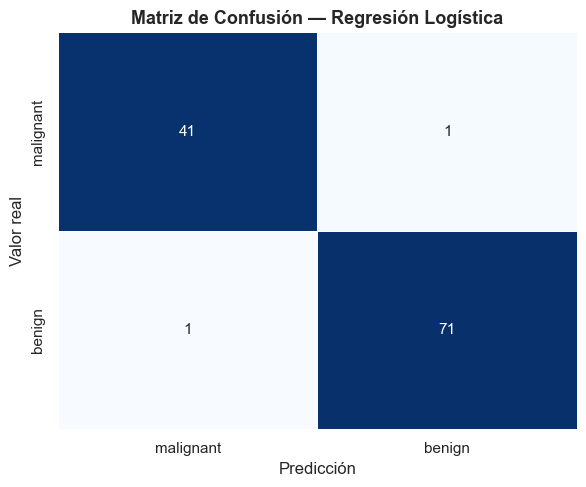

In [5]:
# ━━━ SECCIÓN 1: MÉTRICAS DE CLASIFICACIÓN ━━━

def plot_confusion_matrix(cm, class_names, title='Matriz de Confusión', ax=None):
    """Visualiza una matriz de confusión con anotaciones de porcentaje."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    # Normalizar por fila para obtener tasas
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_xlabel('Predicción', fontsize=12)
    ax.set_ylabel('Valor real', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')


# Entrenar un modelo base con pipeline (evita data leakage)
pipeline_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
pipeline_clf.fit(X_clf_train, y_clf_train)
y_pred = pipeline_clf.predict(X_clf_test)

# Calcular métricas
acc   = accuracy_score(y_clf_test, y_pred)
prec  = precision_score(y_clf_test, y_pred)
rec   = recall_score(y_clf_test, y_pred)
f1    = f1_score(y_clf_test, y_pred)
cm    = confusion_matrix(y_clf_test, y_pred)

# Mostrar resultados interpretados
print('=== Métricas de Clasificación — Breast Cancer Dataset ===')
print(f'  Accuracy  : {acc:.3f}  → El modelo clasifica correctamente el {acc*100:.1f}% de los casos')
print(f'  Precision : {prec:.3f}  → De los que predice como malignos, el {prec*100:.1f}% lo son')
print(f'  Recall    : {rec:.3f}  → De los malignos reales, detecta el {rec*100:.1f}%')
print(f'  F1-Score  : {f1:.3f}  → Balance entre precision y recall')
print()
print(classification_report(y_clf_test, y_pred,
                             target_names=data_clf.target_names))

# Visualizar matriz de confusión
fig, ax = plt.subplots(figsize=(6, 5))
plot_confusion_matrix(cm, class_names=data_clf.target_names,
                      title='Matriz de Confusión — Regresión Logística', ax=ax)
plt.tight_layout()
plt.show()

> 💡 **Punto clave:** En diagnóstico médico, el **recall** (sensibilidad) suele tener más peso que la precision: es peor no detectar una enfermedad real (FN) que enviar a más estudios a alguien sano (FP). La elección de la métrica debe reflejar el **costo asimétrico** de los errores.

| Métrica | Qué penaliza más | Cuándo usarla |
|---------|-----------------|---------------|
| Accuracy | Errores totales | Clases balanceadas |
| Precision | FP | Spam, fraude (costo de molestar al usuario) |
| Recall | FN | Diagnóstico, detección de fallas |
| F1 | FP y FN por igual | Balance general |
| F-beta (β>1) | FN | Cuando el recall es prioritario |

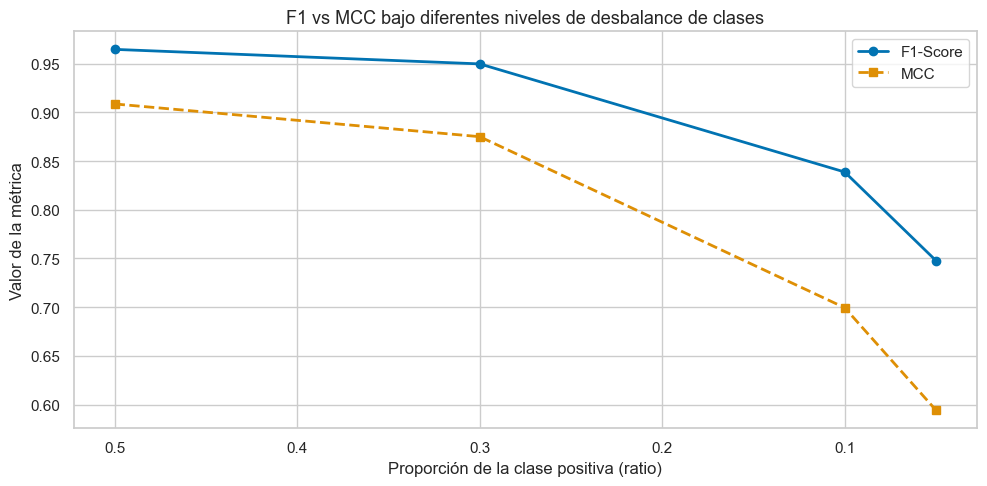

Nota: MCC considera los cuatro cuadrantes de la matriz de confusión simultáneamente.


In [6]:
# [PhD]
# ━━━ EXPERIMENTO PhD: MCC vs F1 bajo desbalance de clases ━━━
from sklearn.metrics import matthews_corrcoef
from sklearn.utils import resample

# Crear versiones con distintos ratios de desbalance
ratios = [0.5, 0.3, 0.1, 0.05]
f1_scores, mcc_scores = [], []

for ratio in ratios:
    # Sub-muestrear la clase positiva para simular desbalance
    idx_pos = np.where(y_clf_train == 1)[0]
    idx_neg = np.where(y_clf_train == 0)[0]
    n_pos = int(len(idx_neg) * ratio / (1 - ratio))
    n_pos = min(n_pos, len(idx_pos))
    idx_pos_sub = resample(idx_pos, n_samples=n_pos, replace=False, random_state=RANDOM_STATE)
    idx_combined = np.concatenate([idx_neg, idx_pos_sub])
    X_sub = X_clf_train.iloc[idx_combined]
    y_sub = y_clf_train.iloc[idx_combined]

    pipe = Pipeline([('sc', StandardScaler()),
                     ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
    pipe.fit(X_sub, y_sub)
    y_p = pipe.predict(X_clf_test)
    f1_scores.append(f1_score(y_clf_test, y_p, zero_division=0))
    mcc_scores.append(matthews_corrcoef(y_clf_test, y_p))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ratios, f1_scores, 'o-', label='F1-Score', linewidth=2)
ax.plot(ratios, mcc_scores, 's--', label='MCC', linewidth=2)
ax.set_xlabel('Proporción de la clase positiva (ratio)', fontsize=12)
ax.set_ylabel('Valor de la métrica', fontsize=12)
ax.set_title('F1 vs MCC bajo diferentes niveles de desbalance de clases', fontsize=13)
ax.legend(fontsize=11)
ax.invert_xaxis()
plt.tight_layout()
plt.show()
print('Nota: MCC considera los cuatro cuadrantes de la matriz de confusión simultáneamente.')

---
## Sección 2 — Curva ROC y AUC

Un clasificador binario no solo produce una etiqueta, sino también una **puntuación** (probabilidad o distancia). La **curva ROC** (Receiver Operating Characteristic) muestra el tradeoff entre la **Tasa de Verdaderos Positivos** (TPR = Recall) y la **Tasa de Falsos Positivos** (FPR) al variar el umbral de decisión $\theta \in [0,1]$:

$$\text{TPR}(\theta) = \frac{TP(\theta)}{TP(\theta) + FN(\theta)}, \qquad \text{FPR}(\theta) = \frac{FP(\theta)}{FP(\theta) + TN(\theta)}$$

El **AUC** (Área Bajo la Curva ROC) resume el desempeño en todos los umbrales: $\text{AUC} \in [0.5, 1]$.

<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">
🔵 Pregrado</span><br><br>

**Analogía:** Imagina un detector de metal en un aeropuerto. Si bajas la sensibilidad, deja pasar más metales (más FN) pero también molesta menos a viajeros inocentes (menos FP). Si la subes, detecta más metales pero genera más falsas alarmas. La curva ROC muestra **todos** estos puntos de operación posibles a la vez.

> 🤔 **Pregunta:** ¿Qué forma tiene la curva ROC de un clasificador aleatorio (que simplemente adivina)? ¿Y la de un clasificador perfecto?

> 🤔 **Pregunta:** Si AUC = 0.85, ¿qué significa en términos probabilísticos?

**Interpretación del AUC:** Probabilidad de que, dado un positivo y un negativo elegidos al azar, el modelo asigne mayor puntuación al positivo. AUC = 0.5 → azar. AUC = 1.0 → perfecto.

<br>
<span style="font-size:0.85em; color:#5D6D7E;">
→ ¿Quieres ver la formalización matemática? Continúa en el bloque 🟡 Doctorado.
</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">
🟡 Doctorado</span><br><br>

**Demostración: AUC = P(score(x⁺) > score(x⁻))**

Sea $s(x) = \hat{P}(Y=1 | x)$ la puntuación del modelo. Para un umbral $\theta$, definimos $h_\theta(x) = \mathbb{1}[s(x) \geq \theta]$.

$$\text{AUC} = \int_0^1 \text{TPR}(\text{FPR}^{-1}(t))\, dt = P(s(X^+) > s(X^-))$$

donde $X^+$ y $X^-$ son muestras independientes de la clase positiva y negativa respectivamente. Esta identidad se demuestra notando que el integrando es equivalente a contar pares discordantes (estadístico Wilcoxon-Mann-Whitney).

**Limitaciones del AUC-ROC:**  
En datasets fuertemente desbalanceados, la FPR se hace pequeña automáticamente (muchos TN), por lo que el AUC-ROC puede ser optimista. La **curva Precision-Recall** (PR-AUC) es más informativa en este caso.

**Relación con el estadístico de Wilcoxon:**  
$$\text{AUC} = \frac{U}{n^+ \cdot n^-}$$
donde $U$ es el estadístico de Mann-Whitney, con $n^+, n^-$ los tamaños de cada clase.

> 📄 **Ref:** Hanley & McNeil (1982). *The meaning and use of the area under a receiver operating characteristic (ROC) curve*. Radiology 143(1). doi:10.1148/radiology.143.1.7063747

> 🔬 **Para investigar:** ¿Bajo qué distribuciones de scores la curva ROC es cóncava? ¿Qué implica una curva ROC no monótona en términos del clasificador?

<br>
<span style="font-size:0.85em; color:#7D6608;">
→ La intuición detrás de esta derivación está en el bloque 🔵 Pregrado.
</span>
</div>

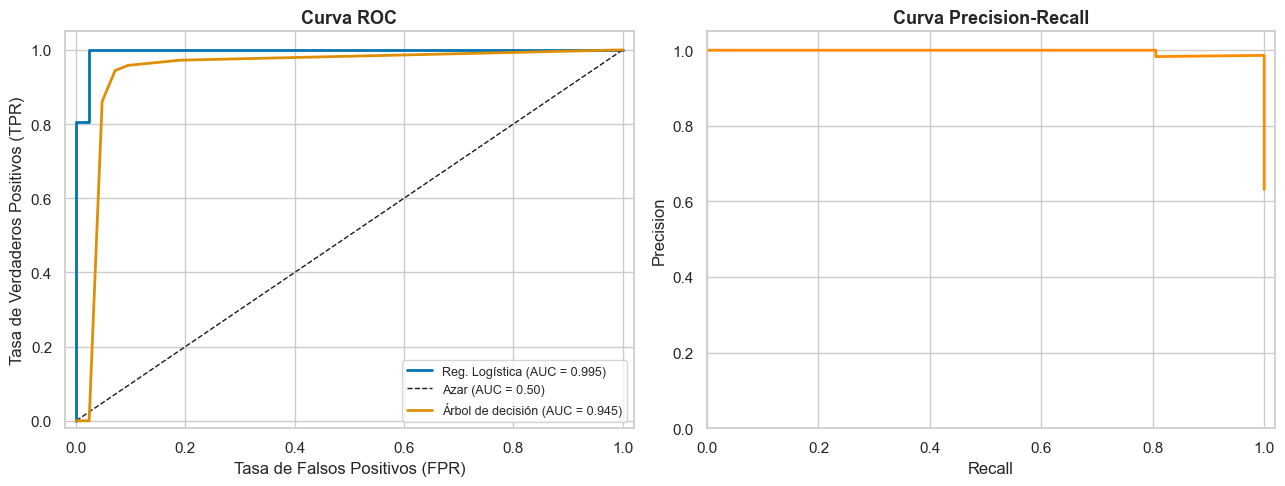

AUC Regresión Logística: 0.995
AUC Árbol de Decisión  : 0.945
→ La Regresión Logística tiene mejor capacidad de separación global


In [7]:
# ━━━ SECCIÓN 2: CURVA ROC Y AUC ━━━

def plot_roc_curve(y_true, y_scores, label='Modelo', ax=None):
    """Traza la curva ROC con AUC en la leyenda."""
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    auc_val = roc_auc_score(y_true, y_scores)
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, linewidth=2, label=f'{label} (AUC = {auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Azar (AUC = 0.50)')
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
    ax.set_title('Curva ROC', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.05])
    return auc_val


# Obtener probabilidades (no solo la etiqueta)
y_prob = pipeline_clf.predict_proba(X_clf_test)[:, 1]

# Comparar con un árbol de decisión como segundo modelo
pipeline_tree = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE))
])
pipeline_tree.fit(X_clf_train, y_clf_train)
y_prob_tree = pipeline_tree.predict_proba(X_clf_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Curva ROC comparativa
auc_lr   = plot_roc_curve(y_clf_test, y_prob, 'Reg. Logística', ax=axes[0])
fpr_t, tpr_t, _ = roc_curve(y_clf_test, y_prob_tree)
auc_tree = roc_auc_score(y_clf_test, y_prob_tree)
axes[0].plot(fpr_t, tpr_t, linewidth=2, label=f'Árbol de decisión (AUC = {auc_tree:.3f})')
axes[0].legend(fontsize=9)

# Curva Precision-Recall
precision_vals, recall_vals, _ = precision_recall_curve(y_clf_test, y_prob)
axes[1].plot(recall_vals, precision_vals, linewidth=2, color='darkorange')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Curva Precision-Recall', fontsize=13, fontweight='bold')
axes[1].set_xlim([0, 1.02])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print(f'AUC Regresión Logística: {auc_lr:.3f}')
print(f'AUC Árbol de Decisión  : {auc_tree:.3f}')
print(f'→ La Regresión Logística tiene mejor capacidad de separación global')

> 💡 **Punto clave:** La curva ROC y el AUC miden la **capacidad discriminativa** del modelo, independiente del umbral elegido. Usar `predict_proba` en lugar de `predict` da acceso a esta información más rica.

---
## Sección 3 — Métricas de Regresión

Para problemas de regresión, las predicciones son continuas $\hat{y} \in \mathbb{R}$. Las métricas miden el **error** entre $y$ e $\hat{y}$:

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^n |y_i - \hat{y}_i|$$

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2 \qquad \text{RMSE} = \sqrt{\text{MSE}}$$

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">
🔵 Pregrado</span><br><br>

**Analogía:** Estimas el precio de casas. El error es la diferencia entre el precio que predijiste y el real. MAE es el error promedio en pesos (directo). MSE castiga más los errores grandes (penaliza el que predijo $500K cuando era $100K). R² dice qué proporción de la variación del precio explica tu modelo (0 = nada, 1 = todo).

> 🤔 **Pregunta:** ¿Por qué MSE castiga más los errores grandes que MAE? Da un ejemplo numérico.

> 🤔 **Pregunta:** ¿Puede R² ser negativo? ¿Qué significaría eso?

**Ejemplo a mano:**  
$y = [3, 5, 7]$, $\hat{y} = [2.5, 5.5, 6.5]$  
MAE = (0.5 + 0.5 + 0.5)/3 = **0.5**  
MSE = (0.25 + 0.25 + 0.25)/3 = **0.25** → RMSE = 0.5  
$\bar{y}$ = 5 → R² = 1 - 0.75/8 = **0.906**

<br>
<span style="font-size:0.85em; color:#5D6D7E;">
→ ¿Quieres ver la formalización matemática? Continúa en el bloque 🟡 Doctorado.
</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">
🟡 Doctorado</span><br><br>

**Propiedades de R²:**  
$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}, \quad SS_{res} = \|y - \hat{y}\|^2, \quad SS_{tot} = \|y - \bar{y}\mathbf{1}\|^2$$

**Paso 1:** $SS_{res} \geq 0$ siempre.  
**Paso 2:** Si $\hat{y}_i = \bar{y}$ (modelo constante), entonces $R^2 = 0$.  
**Paso 3:** Si $\hat{y}$ es peor que la media (modelo negativo), $R^2 < 0$.  
**Paso 4:** En OLS lineal con intercepto, $R^2 = \rho^2(y, \hat{y})$ (correlación al cuadrado).

⚠️ En modelos no lineales o sin intercepto, esta equivalencia no se cumple.

**MAE como estimador de la mediana vs MSE como estimador de la media:**  
El estimador que minimiza MSE es $\mu = E[Y]$ (media).  
El que minimiza MAE es la mediana de $Y$. En distribuciones asimétricas, la mediana es más robusta a outliers.

> 📄 **Ref:** Willmott & Matsuura (2005). *Advantages of the mean absolute error (MAE) over the root mean square error (RMSE) in assessing average model performance*. Climate Research 30. doi:10.3354/cr030079

> 🔬 **Para investigar:** ¿Cuándo es preferible usar el error cuantílico (pinball loss) en lugar de MSE o MAE? ¿Qué relación tiene con la regresión cuantílica?

<br>
<span style="font-size:0.85em; color:#7D6608;">
→ La intuición detrás de esta derivación está en el bloque 🔵 Pregrado.
</span>
</div>

=== Métricas de Regresión — Diabetes Dataset ===
  MAE  : 42.81   → Error promedio absoluto en las unidades del target
  MSE  : 2892.01  → Error cuadrático medio (penaliza errores grandes)
  RMSE : 53.78   → Raíz del MSE (misma escala que el target)
  R²   : 0.454   → El modelo explica el 45.4% de la varianza del target


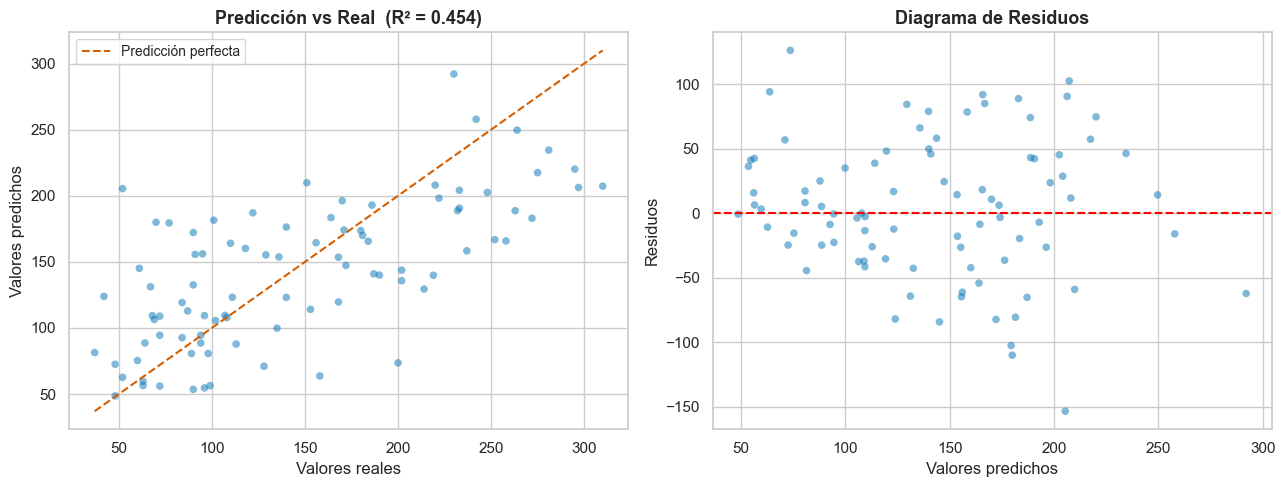

In [8]:
# ━━━ SECCIÓN 3: MÉTRICAS DE REGRESIÓN ━━━

def plot_residuals(y_true, y_pred, title='', ax=None):
    """Diagrama de residuos: predicción vs error."""
    residuals = y_true - y_pred
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y_pred, residuals, alpha=0.5, edgecolors='none', s=30)
    ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Valores predichos', fontsize=12)
    ax.set_ylabel('Residuos', fontsize=12)
    ax.set_title(title or 'Diagrama de Residuos', fontsize=13, fontweight='bold')


# Pipeline de regresión
pipeline_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', Ridge(alpha=1.0))
])
pipeline_reg.fit(X_reg_train, y_reg_train)
y_reg_pred = pipeline_reg.predict(X_reg_test)

# Calcular métricas
mae  = mean_absolute_error(y_reg_test, y_reg_pred)
mse  = mean_squared_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_reg_test, y_reg_pred)

print('=== Métricas de Regresión — Diabetes Dataset ===')
print(f'  MAE  : {mae:.2f}   → Error promedio absoluto en las unidades del target')
print(f'  MSE  : {mse:.2f}  → Error cuadrático medio (penaliza errores grandes)')
print(f'  RMSE : {rmse:.2f}   → Raíz del MSE (misma escala que el target)')
print(f'  R²   : {r2:.3f}   → El modelo explica el {r2*100:.1f}% de la varianza del target')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Predicción vs real
axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.5, edgecolors='none', s=30)
min_val, max_val = y_reg_test.min(), y_reg_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valores reales', fontsize=12)
axes[0].set_ylabel('Valores predichos', fontsize=12)
axes[0].set_title(f'Predicción vs Real  (R² = {r2:.3f})', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Residuos
plot_residuals(y_reg_test, y_reg_pred, title='Diagrama de Residuos', ax=axes[1])

plt.tight_layout()
plt.show()

> 💡 **Punto clave:** RMSE y MAE están en las mismas unidades que el target, lo que facilita su interpretación. Si RMSE >> MAE, hay **outliers** que inflan el error cuadrático. Siempre graficar el diagrama de residuos para detectar patrones sistemáticos.

| Métrica | Unidades | Sensible a outliers | Interpretación directa |
|---------|----------|--------------------|-----------------------|
| MAE | target | Baja | Sí |
| MSE | target² | Alta | No |
| RMSE | target | Alta | Sí |
| R² | adimensional | Media | Sí (% varianza) |

---
## Sección 4 — Validación Cruzada

Un único train/test split puede ser **ruidoso**: depende de qué muestras cayeron en test. La **validación cruzada** (CV) obtiene múltiples estimaciones del error y reduce esta varianza.

**K-fold CV:** Dividir en $k$ particiones. En cada iteración, una partición es test y las $k-1$ restantes son train. El error final es el promedio.

```
k=5:
Fold 1: [TEST] [train] [train] [train] [train]
Fold 2: [train] [TEST] [train] [train] [train]
...     ...
Fold 5: [train] [train] [train] [train] [TEST]
```

<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">
🔵 Pregrado</span><br><br>

**Analogía:** En lugar de rendir un solo examen para evaluar tu nivel, rindas 5 exámenes con diferentes preguntas de la misma materia. El promedio de las 5 notas es más confiable que cualquier nota individual.

> 🤔 **Pregunta:** ¿Por qué es importante hacer el fit del scaler **solo en el train** de cada fold y no en todo el dataset?

> 🤔 **Pregunta:** ¿Cuándo usarías **Stratified** K-Fold en lugar de K-Fold estándar?

**Regla práctica:** k=5 o k=10 son los valores más comunes. k=n (Leave-One-Out) es el caso extremo: máximo uso de datos, pero muy costoso computacionalmente.

<br>
<span style="font-size:0.85em; color:#5D6D7E;">
→ ¿Quieres ver la formalización matemática? Continúa en el bloque 🟡 Doctorado.
</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">
🟡 Doctorado</span><br><br>

**Análisis de varianza del estimador CV:**

Sea $\hat{\epsilon}_j$ el error en el fold $j$. El estimador CV es $\bar{\epsilon}_{CV} = \frac{1}{k} \sum_j \hat{\epsilon}_j$.

**Problema:** Los folds comparten datos de entrenamiento, por lo que $\hat{\epsilon}_j$ no son independientes. Esto hace que los intervalos de confianza habituales sean incorrectos.

**Corrección de Nadeau-Bengio:**  
$$\text{Var}_{corr} = \frac{1}{k} + \frac{n_{test}}{n_{train}} \cdot \text{Var}_{iid}$$

Esta corrección evita la sobreconfianza en los tests de hipótesis comparativos.

**Nested CV (CV anidado):**  
Para evitar el sesgo de selección de modelos, el tuning de hiperparámetros y la evaluación del error deben estar en loops separados:
- Loop externo: estima el error del modelo seleccionado.
- Loop interno: selecciona hiperparámetros (GridSearch).

> 📄 **Ref:** Varma & Simon (2006). *Bias in error estimation when using cross-validation for model selection*. BMC Bioinformatics 7(91). doi:10.1186/1471-2105-7-91

> 🔬 **Para investigar:** ¿Cuál es el sesgo asintótico del estimador LOO bajo error cuadrático? ¿En qué régimen de $n$ y $p$ se convierte en un problema?

<br>
<span style="font-size:0.85em; color:#7D6608;">
→ La intuición detrás de esta derivación está en el bloque 🔵 Pregrado.
</span>
</div>

In [ ]:
# ━━━ SECCIÓN 4: VALIDACIÓN CRUZADA ━━━

# Pipeline para CV (el scaler se fittea solo dentro de cada fold)
pipeline_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Usar TODOS los datos para CV (no solo el split anterior)
N_SPLITS = 10

# K-Fold estándar
kf      = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scores_kf = cross_val_score(pipeline_cv, X_clf, y_clf, cv=kf, scoring='f1')

# Stratified K-Fold (mantiene proporción de clases en cada fold)
skf     = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scores_skf = cross_val_score(pipeline_cv, X_clf, y_clf, cv=skf, scoring='f1')

# Leave-One-Out (costoso, usar con pocos datos)
# Limitamos a 100 muestras para demostración
X_small = X_clf.iloc[:100]
y_small = y_clf.iloc[:100]
loo     = LeaveOneOut()
scores_loo = cross_val_score(pipeline_cv, X_small, y_small, cv=loo, scoring='f1')

print('=== Comparación de estrategias de Validación Cruzada ===')
print(f'K-Fold (k={N_SPLITS})          : {scores_kf.mean():.3f} ± {scores_kf.std():.3f}')
print(f'Stratified K-Fold (k={N_SPLITS}): {scores_skf.mean():.3f} ± {scores_skf.std():.3f}')
print(f'Leave-One-Out (n=100)    : {scores_loo.mean():.3f} ± {scores_loo.std():.3f}')

# Visualizar distribución de scores por fold
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot comparativo
axes[0].boxplot([scores_kf, scores_skf], labels=['K-Fold', 'Stratified\nK-Fold'], patch_artist=True)
axes[0].set_ylabel('F1-Score por fold', fontsize=12)
axes[0].set_title('Distribución del F1 por tipo de CV', fontsize=13, fontweight='bold')
axes[0].set_ylim([0.85, 1.01])

# Scores por fold
axes[1].plot(range(1, N_SPLITS+1), scores_kf, 'o-', label='K-Fold', linewidth=2)
axes[1].plot(range(1, N_SPLITS+1), scores_skf, 's--', label='Stratified K-Fold', linewidth=2)
axes[1].axhline(scores_kf.mean(), color='C0', linestyle=':', alpha=0.7, linewidth=1.5)
axes[1].axhline(scores_skf.mean(), color='C1', linestyle=':', alpha=0.7, linewidth=1.5)
axes[1].set_xlabel('Fold', fontsize=12)
axes[1].set_ylabel('F1-Score', fontsize=12)
axes[1].set_title('F1-Score por fold', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

> 💡 **Punto clave:** Usar un `Pipeline` en validación cruzada es **obligatorio** para evitar data leakage: el `StandardScaler` (u otra transformación) debe fitearse **solo** en los datos de entrenamiento de cada fold, nunca en el test.

| Estrategia | Uso de datos | Costo computacional | Cuándo usarla |
|-----------|-------------|---------------------|---------------|
| K-Fold (k=5) | Moderado | Bajo | Caso general |
| Stratified K-Fold | Moderado | Bajo | Clasificación con desbalance |
| LOO | Máximo | Muy alto | Datasets pequeños (n < 100) |

---
## Sección 5 — Curvas de Aprendizaje y Validación

Dos herramientas clave para **diagnosticar** el comportamiento del modelo:

- **Curva de aprendizaje:** error de train y validación en función del **tamaño del conjunto de entrenamiento** → diagnostica si más datos ayudan.
- **Curva de validación:** error de train y validación en función de un **hiperparámetro** → diagnostica el tradeoff bias-varianza.

<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">
🔵 Pregrado</span><br><br>

**Patrones a reconocer en la curva de aprendizaje:**

```
Alto bias (underfitting):          Alto varianza (overfitting):
   error                               error
    │                                   │  ─── train (bajo)
    │── valid (alto)                    │
    │── train (alto)                    │  ─ ─ ─ ─ ─ valid (alto)
    └────────────────►                  └────────────────►
       tamaño train                        tamaño train
```

> 🤔 **Pregunta:** Si la curva de validación sube y la de train baja al aumentar la regularización, ¿el modelo original tenía alto bias o alta varianza?

<br>
<span style="font-size:0.85em; color:#5D6D7E;">
→ ¿Quieres ver la formalización matemática? Continúa en el bloque 🟡 Doctorado.
</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">
🟡 Doctorado</span><br><br>

**Descomposición Bias-Varianza:**

Para el error cuadrático esperado en un punto $x$:
$$E[(y - \hat{f}(x))^2] = \underbrace{\text{Bias}^2[\hat{f}(x)]}_{\text{error sistemático}} + \underbrace{\text{Var}[\hat{f}(x)]}_{\text{sensibilidad a datos}} + \underbrace{\sigma^2}_{\text{ruido irreducible}}$$

**Interpretación de las curvas:**  
- Si train y valid convergen a un error alto → alto bias: el modelo está sesgado, más datos no ayudan, necesita mayor complejidad.
- Si hay gran brecha entre train y valid → alta varianza: el modelo memoriza, necesita regularización o más datos.

**Implicación de la curva de validación:**  
La zona óptima del hiperparámetro minimiza $\text{Bias}^2 + \text{Varianza}$. A la izquierda del óptimo hay underfitting; a la derecha, overfitting.

> 📄 **Ref:** Geman et al. (1992). *Neural Networks and the Bias/Variance Dilemma*. Neural Computation 4(1). doi:10.1162/neco.1992.4.1.1

> 🔬 **Para investigar:** ¿En qué regime de $n$ y $d$ (dimensión) colapsa el tradeoff bias-varianza en modelos sobre-parametrizados (double descent)?

<br>
<span style="font-size:0.85em; color:#7D6608;">
→ La intuición detrás de esta derivación está en el bloque 🔵 Pregrado.
</span>
</div>

In [ ]:
# ━━━ SECCIÓN 5: CURVAS DE APRENDIZAJE Y VALIDACIÓN ━━━

def plot_learning_curve(estimator, X, y, title='', cv=5, ax=None):
    """Curva de aprendizaje: error de train y CV vs tamaño del training set."""
    train_sizes = np.linspace(0.1, 1.0, 10)
    train_s, train_scores, val_scores = learning_curve(
        estimator, X, y,
        train_sizes=train_sizes,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1', n_jobs=-1
    )
    train_mean = 1 - train_scores.mean(axis=1)
    val_mean   = 1 - val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))
    ax.plot(train_s, train_mean, 'o-', label='Error entrenamiento', linewidth=2)
    ax.plot(train_s, val_mean,  's--', label='Error validación (CV)', linewidth=2)
    ax.fill_between(train_s, val_mean - val_std, val_mean + val_std, alpha=0.15)
    ax.set_xlabel('Tamaño del conjunto de entrenamiento', fontsize=12)
    ax.set_ylabel('Error (1 - F1)', fontsize=12)
    ax.set_title(title or 'Curva de Aprendizaje', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)


def plot_validation_curve(estimator, X, y, param_name, param_range, title='', ax=None):
    """Curva de validación: error de train y CV vs hiperparámetro."""
    train_scores, val_scores = validation_curve(
        estimator, X, y,
        param_name=param_name, param_range=param_range,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1'
    )
    train_mean = 1 - train_scores.mean(axis=1)
    val_mean   = 1 - val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))
    ax.semilogx(param_range, train_mean, 'o-', label='Error entrenamiento', linewidth=2)
    ax.semilogx(param_range, val_mean,  's--', label='Error validación (CV)', linewidth=2)
    ax.fill_between(param_range, val_mean - val_std, val_mean + val_std, alpha=0.15)
    ax.set_xlabel(param_name, fontsize=12)
    ax.set_ylabel('Error (1 - F1)', fontsize=12)
    ax.set_title(title or f'Curva de Validación ({param_name})', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)


# Curva de aprendizaje para Regresión Logística
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Curva de validación para Árbol de Decisión (hiperparámetro: max_depth)
tree_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE))
])
PARAM_RANGE = np.arange(1, 21)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_learning_curve(lr_pipe, X_clf, y_clf,
                    title='Curva de Aprendizaje — Reg. Logística', ax=axes[0])
plot_validation_curve(tree_pipe, X_clf, y_clf,
                      param_name='clf__max_depth', param_range=PARAM_RANGE,
                      title='Curva de Validación — Árbol de Decisión (max_depth)', ax=axes[1])
plt.tight_layout()
plt.show()

print('Observación: El árbol con max_depth > 8 muestra sobreajuste (brecha train/valid creciente).')

> ⚠️ **Advertencia:** La curva de validación usa CV en **todo el dataset** para cada valor del hiperparámetro. Si luego usas ese hiperparámetro óptimo para reportar el error final, estás introduciendo **sesgo de selección**. Para un reporte honesto, usa **Nested CV**.

---
## Sección 6 — Ejercicio en Clase

### Parte A — Sin computador (10 min) ✏️

Un modelo de clasificación binaria produce los siguientes resultados sobre 8 muestras de test:

| Muestra | Real (y) | Predicho (ŷ) | Score P(y=1) |
|---------|----------|-------------|-------------|
| 1 | 1 | 1 | 0.91 |
| 2 | 0 | 0 | 0.12 |
| 3 | 1 | 0 | 0.45 |
| 4 | 0 | 1 | 0.68 |
| 5 | 1 | 1 | 0.82 |
| 6 | 0 | 0 | 0.30 |
| 7 | 1 | 1 | 0.77 |
| 8 | 0 | 0 | 0.21 |

**Responde en tu cuaderno:**  
1. Construye la matriz de confusión manualmente.  
2. Calcula Accuracy, Precision, Recall y F1.  
3. Si cambiamos el umbral a 0.70, ¿qué cambia en la matriz de confusión?

In [ ]:
# ── Verificación del ejercicio sin computador ── (ejecutar DESPUÉS de responder)
y_real = np.array([1, 0, 1, 0, 1, 0, 1, 0])
y_hat  = np.array([1, 0, 0, 1, 1, 0, 1, 0])  # umbral 0.5
scores = np.array([0.91, 0.12, 0.45, 0.68, 0.82, 0.30, 0.77, 0.21])

cm_ej = confusion_matrix(y_real, y_hat)
print('=== Verificación Ejercicio A ===')
print('Matriz de Confusión:')
print(cm_ej)
print(f'Accuracy : {accuracy_score(y_real, y_hat):.3f}')
print(f'Precision: {precision_score(y_real, y_hat):.3f}')
print(f'Recall   : {recall_score(y_real, y_hat):.3f}')
print(f'F1       : {f1_score(y_real, y_hat):.3f}')
print()

# Umbral 0.70
y_hat_07 = (scores >= 0.70).astype(int)
cm_07 = confusion_matrix(y_real, y_hat_07)
print('Con umbral = 0.70:')
print(cm_07)
print(f'Accuracy : {accuracy_score(y_real, y_hat_07):.3f}')
print(f'Precision: {precision_score(y_real, y_hat_07):.3f}')
print(f'Recall   : {recall_score(y_real, y_hat_07):.3f}')

### Parte B — Ejercicio de código (en clase, 15 min) 💻

<div style="background-color:#EBF5FB; border-left:5px solid #2E86C1;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#2E86C1; font-weight:bold; font-size:1em;">🔵 Pregrado</span><br><br>

Usando el dataset `load_digits()` de sklearn con las clases 0 y 1 (clasificación binaria):
1. Crea un pipeline con StandardScaler + LogisticRegression.
2. Evalúa con **Stratified 5-Fold CV** y reporta el F1-Score promedio ± desviación estándar.
3. Grafica la curva ROC.

<br>
<span style="font-size:0.85em; color:#5D6D7E;">→ ¿Quieres ver la versión avanzada? Continúa en el bloque 🟡 Doctorado.</span>
</div>

<div style="background-color:#FEFDE7; border-left:5px solid #D4AC0D;
     padding:14px 18px; border-radius:6px; margin:12px 0;">
<span style="color:#B7950B; font-weight:bold; font-size:1em;">🟡 Doctorado</span><br><br>

Además del punto anterior:
4. Implementa **Nested CV** (loop externo: 5-fold, loop interno: GridSearch sobre C de LR).
5. Compara el F1 del modelo con y sin nested CV. ¿Hay sesgo de selección?
6. Grafica la curva de validación para el hiperparámetro C en el rango logspace(-3, 3, 20).

<br>
<span style="font-size:0.85em; color:#7D6608;">→ La intuición detrás de esta derivación está en el bloque 🔵 Pregrado.</span>
</div>

In [ ]:
# Espacio de trabajo para el ejercicio en clase
from sklearn.datasets import load_digits
from sklearn.model_selection import GridSearchCV, cross_validate

# Cargar solo clases 0 y 1
digits = load_digits()
mask = digits.target < 2
X_dig = digits.data[mask]
y_dig = digits.target[mask]

# ── Tu código aquí ──


---
## Resumen Final

| Concepto | Definición corta | Cuándo usarlo |
|----------|-----------------|---------------|
| Accuracy | Fracción de predicciones correctas | Clases balanceadas |
| Precision / Recall | TP sobre predichos / sobre reales | Costos asimétricos de errores |
| F1 | Media harmónica precision-recall | Balance general clasificación |
| AUC-ROC | Prob. de rankear positivo antes que negativo | Ranking / evaluación umbral-independiente |
| MAE / RMSE / R² | Errores de regresión en distintas escalas | Regresión continua |
| K-Fold CV | Promedio de k evaluaciones | Estimación robusta del error |
| Learning curve | Error vs tamaño de train | Diagnosticar bias/varianza |
| Validation curve | Error vs hiperparámetro | Selección de hiperparámetros |

**Conexión con la próxima clase:** Con estas herramientas de evaluación ya en mano, la siguiente clase aborda **selección y comparación de modelos**: cómo elegir entre varios candidatos y testear estadísticamente si las diferencias son significativas.

---
## Bibliografía

### Pregrado
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly. Cap. 3.
- Müller, A. C. & Guido, S. (2016). *Introduction to Machine Learning with Python*. O'Reilly. Cap. 5.

### Doctorado / Investigación
- Sokolova & Lapalme (2009). *A systematic analysis of performance measures for classification tasks*. Information Processing & Management. doi:10.1016/j.ipm.2009.03.002
- Varma & Simon (2006). *Bias in error estimation when using CV for model selection*. BMC Bioinformatics. doi:10.1186/1471-2105-7-91
- Geman et al. (1992). *Neural Networks and the Bias/Variance Dilemma*. Neural Computation. doi:10.1162/neco.1992.4.1.1
- Hanley & McNeil (1982). *The meaning and use of the area under a ROC curve*. Radiology. doi:10.1148/radiology.143.1.7063747